🟦 AICE Associate 실전 연습문제 - 분류 문제 Set (Classification, 총 14문항)  
📘 시나리오  
운행 기록 데이터를 기반으로 is_abnormal (이상 주행 여부) 분류 모델을 학습합니다.  
이상 기준: 평균 속도 > 120km/h 또는 주행 거리 / 시간 결측값 존재  

문제 1
데이터를 불러오고 첫 5행을 출력하세요.
파일명: A0007IT.json

In [30]:
import pandas as pd

df = pd.read_json('A0007IT.json')

df.head(5)

,RID,Time_Departure,Time_Arrival,Distance,Time_Driving,Speed_Per_Hour,Address1,Address2,Weekday,Hour,Day
0,R00001,2023-05-21 07:14:00,2023-05-21 07:19:42,10144.0,342.0,89.0,경기도,수원시,Sunday,7,21
1,R00002,2023-04-30 16:38:00,2023-04-30 16:39:47,2739.0,107.0,89.0,서울특별시,서초구,Sunday,16,30
2,R00003,2023-03-23 22:27:00,2023-03-23 23:02:10,23298.0,2110.0,47.0,서울특별시,강남구,Thursday,22,23
3,R00004,2023-07-03 11:38:00,2023-07-03 11:52:18,18335.0,858.0,78.0,서울특별시,강남구,Monday,11,3
4,R00005,2023-05-31 20:39:00,2023-05-31 21:22:18,24700.0,2598.0,28.0,경기도,부천시,Wednesday,20,31


문제 2
avg_speed (km/h) 컬럼을 생성하세요.

계산식: Distance / Time_Driving * 3.6

In [31]:
df['avg_speed'] = df['Distance'] / df['Time_Driving'] * 3.6

df.head(5)

,RID,Time_Departure,Time_Arrival,Distance,Time_Driving,Speed_Per_Hour,Address1,Address2,Weekday,Hour,Day,avg_speed
0,R00001,2023-05-21 07:14:00,2023-05-21 07:19:42,10144.0,342.0,89.0,경기도,수원시,Sunday,7,21,106.778947
1,R00002,2023-04-30 16:38:00,2023-04-30 16:39:47,2739.0,107.0,89.0,서울특별시,서초구,Sunday,16,30,92.153271
2,R00003,2023-03-23 22:27:00,2023-03-23 23:02:10,23298.0,2110.0,47.0,서울특별시,강남구,Thursday,22,23,39.750142
3,R00004,2023-07-03 11:38:00,2023-07-03 11:52:18,18335.0,858.0,78.0,서울특별시,강남구,Monday,11,3,76.930070
4,R00005,2023-05-31 20:39:00,2023-05-31 21:22:18,24700.0,2598.0,28.0,경기도,부천시,Wednesday,20,31,34.226328


문제 3
avg_speed > 120이거나 Distance 또는 Time_Driving이 결측치인 경우 is_abnormal = 1, 아니면 0인 컬럼을 만드세요.

In [32]:
df['is_abnormal'] = ((df['avg_speed'] > 120) | (df['Distance'].isnull()) | (df['Time_Driving'].isnull()) ).astype(int)

문제 4
is_abnormal 비율을 출력하세요.

In [33]:
df['is_abnormal'].value_counts()

is_abnormal
0    957
1     43
Name: count, dtype: int64

문제 5
결측값을 제거한 학습용 DataFrame을 생성하세요.
제외 컬럼: Distance, Time_Driving 중 결측치 포함 행

In [34]:
new_df = df.dropna(subset=['Distance','Time_Driving'])


new_df.isna().sum()

RID               0
Time_Departure    0
Time_Arrival      0
Distance          0
Time_Driving      0
Speed_Per_Hour    6
Address1          0
Address2          8
Weekday           0
Hour              0
Day               0
avg_speed         0
is_abnormal       0
dtype: int64

문제 6
범주형 컬럼 (Weekday, Address1, Address2)을 더미 변수로 변환하세요.

In [35]:
dummy_df = pd.get_dummies(new_df, columns=['Weekday', 'Address1', 'Address2'])


dummy_df.head(1)

,RID,Time_Departure,Time_Arrival,Distance,Time_Driving,Speed_Per_Hour,Hour,Day,avg_speed,is_abnormal,...,Address2_송파구,Address2_수성구,Address2_수원시,Address2_안산시,Address2_연수구,Address2_용인시,Address2_유성구,Address2_종로구,Address2_중구,Address2_해운대구
0,R00001,2023-05-21 07:14:00,2023-05-21 07:19:42,10144.0,342.0,89.0,7,21,106.778947,0,...,False,False,True,False,False,False,False,False,False,False


문제 7
타겟: is_abnormal, 그 외는 Feature로 설정하여 X, y를 분리하세요.

In [37]:

dummy_df.info()


y = dummy_df['is_abnormal']
X = dummy_df.drop(columns=['RID', 'Time_Departure', 'Time_Arrival', 'is_abnormal'])


<class 'pandas.core.frame.DataFrame'>
Index: 979 entries, 0 to 999
Data columns (total 53 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RID                979 non-null    object 
 1   Time_Departure     979 non-null    object 
 2   Time_Arrival       979 non-null    object 
 3   Distance           979 non-null    float64
 4   Time_Driving       979 non-null    float64
 5   Speed_Per_Hour     973 non-null    float64
 6   Hour               979 non-null    int64  
 7   Day                979 non-null    int64  
 8   avg_speed          979 non-null    float64
 9   is_abnormal        979 non-null    int64  
 10  Weekday_Friday     979 non-null    bool   
 11  Weekday_Monday     979 non-null    bool   
 12  Weekday_Saturday   979 non-null    bool   
 13  Weekday_Sunday     979 non-null    bool   
 14  Weekday_Thursday   979 non-null    bool   
 15  Weekday_Tuesday    979 non-null    bool   
 16  Weekday_Wednesday  979 non-null

문제 8
훈련/테스트 데이터셋을 8:2 비율로 나누세요.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.2, random_state=42
)

문제 9
RandomForestClassifier로 모델을 학습하세요.

In [41]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.fit(X_train, y_train)

RandomForestClassifier()

문제 10
검증셋에 대한 정확도(accuracy_score)를 출력하세요.

In [44]:

print("score을 이용한 정확도 : ", clf.score(X_train, y_train))

from sklearn.metrics import accuracy_score

clf_pred = clf.predict(X_test)
print("accuracy_score 메소드를 이용한 정확도 : " , accuracy_score(y_test, clf_pred))


score을 이용한 정확도 :  1.0
accuracy_score 메소드를 이용한 정확도 :  1.0


문제 11
Confusion Matrix를 출력하세요.

confusion_matrix :  [[193   0]
 [  0   3]]


<Axes: >

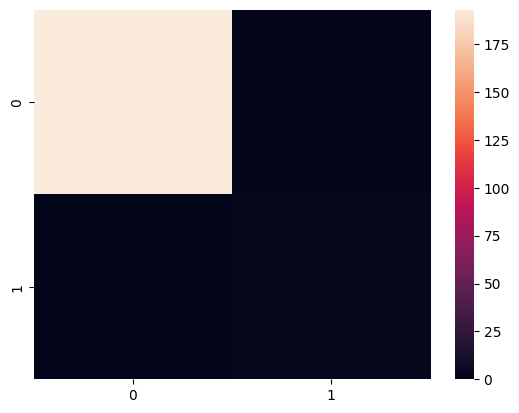

In [47]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("confusion_matrix : " , confusion_matrix(y_test, clf_pred))

## histmap으로 표현하기
sns.heatmap(confusion_matrix(y_test, clf_pred))


문제 12
ROC AUC 점수를 계산하세요.

In [49]:
from sklearn.metrics import roc_auc_score

print("ROC AUC 점수는 : " , roc_auc_score(y_test, clf.predict_proba(X_test)[:,1]))

ROC AUC 점수는 :  1.0


문제 13
중요 변수 상위 10개를 막대 그래프로 시각화하세요.

/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49569 (\N{HANGUL SYLLABLE SONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


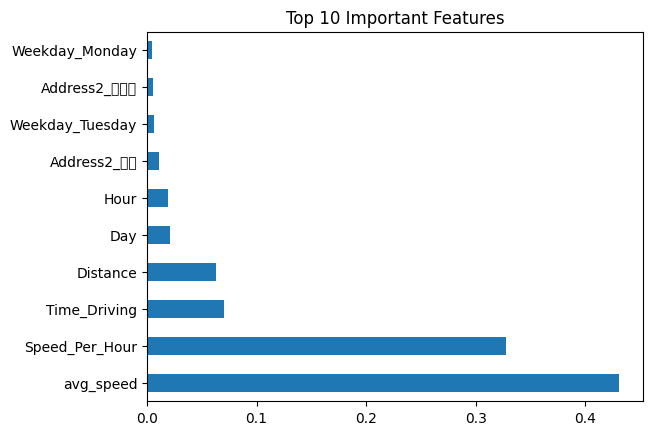

In [50]:
import matplotlib.pyplot as plt

s = pd.Series(clf.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

문제 14
학습된 모델을 classification_model.pkl로 저장하세요.

